In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import seasonal_decompose, STL

### Components of a time series
- three components: a **trend**, a **seasonal component**, and **residuals**: all time series can be decomposed into these three elements
- **Decomposition**: Visualizing the components of a time series is known as decomposition, a statistical task that separates a time series into its different components
- We can visualize each individual component, which will help us identify the trend and seasonal pattern in the data, which is not always straightforward just by looking at a dataset.

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


- The pandas.DatetimeIndex method creates an index of datetime objects, enabling efficient time-based indexing, slicing, and operations in a DataFrame or Series.

In [4]:
df['year'] = pd.DatetimeIndex(df['date']).year
df.head()

,date,data,year
0,1960-01-01,0.71,1960
1,1960-04-01,0.63,1960
2,1960-07-02,0.85,1960
3,1960-10-01,0.44,1960
4,1961-01-01,0.61,1961


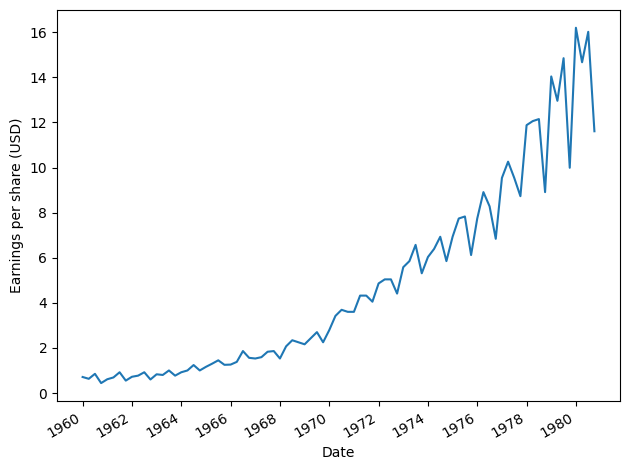

In [6]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F01_peixeiro.png', dpi=300)

In [7]:
advanced_decomposition = STL(df.data, period=4).fit()

**Observed data was split into Trend, Seasonal, and Residuals.**
- Observed, simply shows the time series as it was recorded
- The **trend** is defined as the slow-moving changes in a time series. The trend component is sometimes referred to as the **level**
    - We can think of the trend component as trying to draw a line through most of the data points to show the gen- eral direction of a time series.
- The **seasonal component** captures the seasonal variation, which is a cycle that occurs over a fixed period of time. (Notice how the y-axis shows negative value)
    - the **seasonal component** shows how we deviate from the trend.
- the **residuals**, which is what cannot be explained by either the trend or the seasonal components
    - We can think of the residuals as adding the Trend and Seasonal graphs together and comparing the value at each point in time to the Observed graph. 
    - For certain points, we might get the exact same value as in Observed, in which case the residual will be zero. 
    - In other cases, the value is different from the one in Observed, so the Residuals graph shows what value must be added to Trend and Seasonal in order to adjust the result and get the same value as in Observed.
    - Residuals usually correspond to random errors, also termed **white noise**

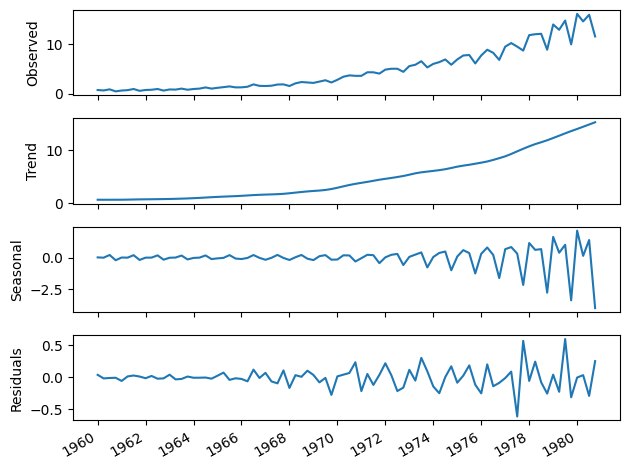

In [8]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True)

ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')


plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F02_peixeiro.png', dpi=300)

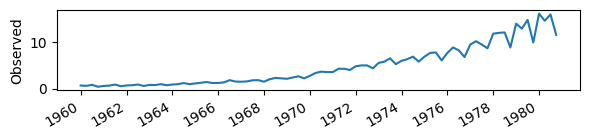

In [9]:
fig, ax = plt.subplots(figsize=(6, 1.5))

ax.plot(advanced_decomposition.observed)
ax.set_ylabel('Observed')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F03_peixeiro.png', dpi=300)

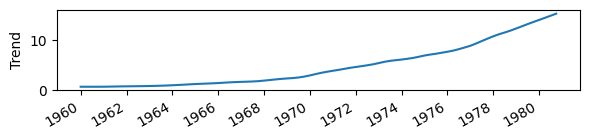

In [10]:
fig, ax = plt.subplots(figsize=(6, 1.5))

ax.plot(advanced_decomposition.trend)
ax.set_ylabel('Trend')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F04_peixeiro.png', dpi=300)

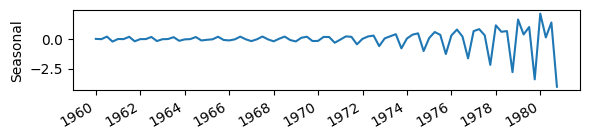

In [11]:
fig, ax = plt.subplots(figsize=(6, 1.5))

ax.plot(advanced_decomposition.seasonal)
ax.set_ylabel('Seasonal')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F05_peixeiro.png', dpi=300)

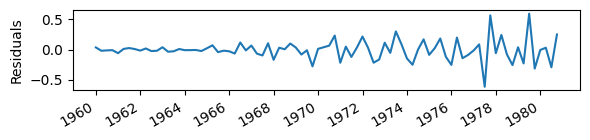

In [12]:
fig, ax = plt.subplots(figsize=(6, 1.5))

ax.plot(advanced_decomposition.resid)
ax.set_ylabel('Residuals')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH01_F06_peixeiro.png', dpi=300)

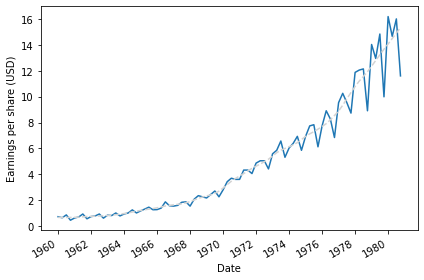

In [12]:
# fig, ax = plt.subplots()

# ax.plot(df.date, df.data)
# ax.plot(advanced_decomposition.trend, color='lightgrey', linestyle='--', label='Trend')
# ax.set_xlabel('Date')
# ax.set_ylabel('Earnings per share (USD)')

# plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# fig.autofmt_xdate()
# plt.tight_layout()

# plt.savefig('figures/CH01_F01_peixeiro.png', dpi=300)

## Gathering Data
- you could collect historical daily minimum temperature data. You could also gather data on possible factors that can influence temperature, such as humidity and wind speed
- This is when the question of how much data is enough data arises. 
     - Ideally, you would collect more than 1 year of data. That way, you could determine if there is a yearly seasonal pattern or a trend. In the case of temperature, you can of course expect some seasonal pattern over the year.
     - However, 1 year of data is not the ultimate answer to how much data is sufficient. It highly depends on the frequency of the forecasts.
     - If you observe seasonality, then a SARIMA model would be relevant, because this model uses seasonal effects to produce forecasts. If you have information on wind speed and humidity, you could take that into account using the SARIMAX model.
     - Unlike statistical learning methods, deep learning tends to produce better models, as more data is used for training.
     - The model’s performance can be assessed by computing an error metric, such as the mean squared error (MSE).
     - You can also look for unexpected events. For example, a heat wave can arise, degrading the quality of your model’s forecasts.

- you will have made many forecasts, assessed their quality against newly observed data, and retrained your model with new daily minimum temperatures as you recorded them.
-At first glance, time series forecasting seems like a typical regression problem: we have some historical data, and we wish to build a mathematical expression that will express future values as a function of past values. 
    - However, there are some key differences between time series forecasting and regres- sion for time-independent scenarios that deserve to be addressed before we look at our very first forecasting technique.
    - **Time series have an order**: we must keep the data in order, so as to not vio- late this relationship.
        - time series are indexed by time, and that order must be kept. Otherwise, you would be training your model with future information that it would not have at prediction time. This is called **look-ahead bias** in more formal terms.
    - **Time series sometimes do not have features**: However, with time series, it is quite common to be given a simple dataset with a time column and a value at that point in time. Without any other features, we must learn ways of using past values of the time series to forecast future values    


